In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import os

plot_dir = "/home/bbc8731/NetMedGPT/data/plot/zero_shot/"
data_dir_NetMedGPT = "/home/bbc8731/NetMedGPT/data/result/NetMedGPT_atr_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250705_221211/"
# queried_edge_types = ['indication', 'contraindication']

In [4]:
Lp_test = pd.read_csv(os.path.join(data_dir_NetMedGPT, "LP_test.csv"))


In [5]:
seeds = [42, 43, 44, 45, 46]

# Group by seed
grouped = Lp_test.groupby('seed')
# Extract the first and second rows per seed
indication_auprcs = grouped.nth(0)['auprc']
contraindication_auprcs = grouped.nth(1)['auprc']

# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
mean_contraindication_auprcs = round(contraindication_auprcs.mean(), 2)


std_indication_auprcs = round(indication_auprcs.std(), 2)
std_contraindication_auprcs = round(contraindication_auprcs.std(),2)


print(f"Mean AUPRC of first entries per seed: {mean_indication_auprcs:.6f}")
print(f"Mean AUPRC of second entries per seed: {mean_contraindication_auprcs:.6f}")


Mean AUPRC of first entries per seed: 0.960000
Mean AUPRC of second entries per seed: 0.880000


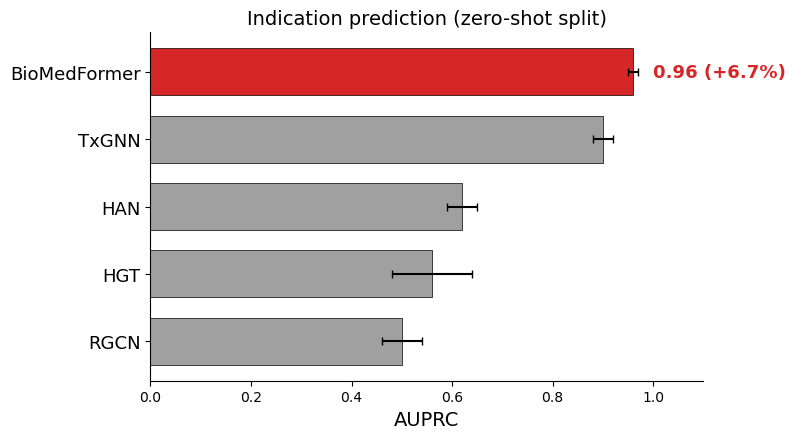

In [11]:
# AUPRC values for indication–zero shot
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]
means = [0.50, 0.56, 0.62, 0.90, mean_indication_auprcs]
stds = [0.04, 0.08, 0.03, 0.02, std_indication_auprcs]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "NetMedGPT_indication_zero_shot.png"), dpi=300, bbox_inches="tight")
plt.show()


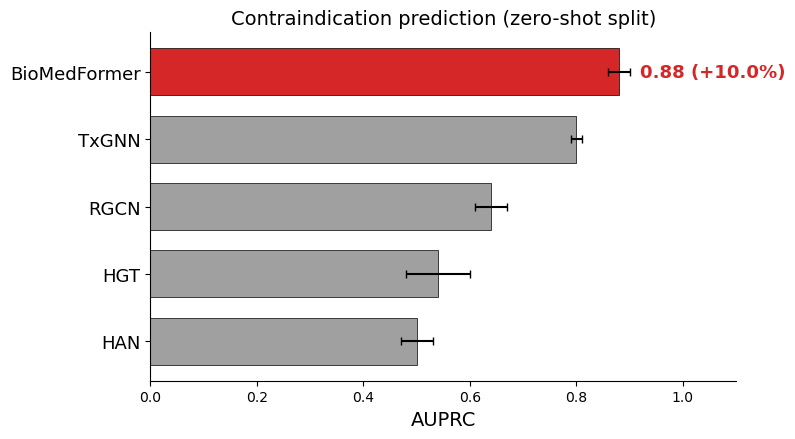

In [10]:
# AUPRC values for contraindication–zero-shot
methods = ["HAN", "HGT",  "RGCN", "TxGNN", "NetMedGPT"]
means = [0.50, 0.54, 0.64, 0.80, mean_contraindication_auprcs]
stds = [0.03, 0.06, 0.03, 0.01, std_contraindication_auprcs]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding
fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "NetMedGPT_contraindication_zero_shot.png"), dpi=300, bbox_inches="tight")
plt.show()
